### Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ks_2samp

### Load Datasets & Data Preprocessing

#### Description of features
- **WDIR**: Wind direction
- **WSPD**: Wind speed
- **rWSPD**: Lagged wind speed
- **rWSPD_T**: Transformed lagged wind speed
- **Fetch**: Fetch distance (*F*)
- **u**: Transformed wind speed
- **uSq**: $u^2$
- **uSq_e**: East component of $u^2$
- **uSq_n**: North component of $u^2$
- $Z_1 = u\sqrt{F}$
- $Z_2 = \frac{F^{3/2}}{u}$

#### Description of target
- **SWHft**: Significant wave height (*H*)

In [2]:
wind_cols = ['uSq','F','uSq_e','uSq_n','Z1','Z2']

# Load datasets
df_buoy_04_13 = pd.read_csv('Data_Buoy_2004_2013.csv')
df_stn_04_13 = pd.read_csv('Data_Sikorsky_2004_2013.csv')
df_stn_73_04 = pd.read_csv('Data_Sikorsky_1973_2004.csv')

# Rename columns
df_buoy_04_13 = df_buoy_04_13.rename(columns={'SWHft':'H'})
df_stn_04_13 = df_stn_04_13.rename(columns={'Fetch':'F'})
df_stn_73_04 = df_stn_73_04.rename(columns={'Fetch':'F'})

# Add transformed wind speed (u)
df_stn_04_13['u'] = df_stn_04_13['rWSPD_T'].shift(-1).ffill()
df_stn_73_04['u'] = df_stn_73_04['rWSPD_T'].shift(-1).ffill()

# Add squared terms (u^2)
df_stn_04_13['uSq'] = df_stn_04_13['u']**2
df_stn_73_04['uSq'] = df_stn_73_04['u']**2

# Add east and north components (uSq_e, uSq_n)
alpha = -13
df_stn_04_13['rad'] = np.pi/180 * ((alpha + 630 - df_stn_04_13['WDIR']) % 360)
df_stn_73_04['rad'] = np.pi/180 * ((alpha + 630 - df_stn_73_04['WDIR']) % 360)
df_stn_04_13['uSq_e'] = df_stn_04_13['uSq'] * np.cos(df_stn_04_13['rad'])
df_stn_73_04['uSq_e'] = df_stn_73_04['uSq'] * np.cos(df_stn_73_04['rad'])
df_stn_04_13['uSq_n'] = df_stn_04_13['uSq'] * np.sin(df_stn_04_13['rad'])
df_stn_73_04['uSq_n'] = df_stn_73_04['uSq'] * np.sin(df_stn_73_04['rad'])

# Add interaction terms (Z1, Z2)
df_stn_04_13['Z1'] = np.sqrt(df_stn_04_13['F']) * df_stn_04_13['u']
df_stn_73_04['Z1'] = np.sqrt(df_stn_73_04['F']) * df_stn_73_04['u']
df_stn_04_13['Z2'] = (df_stn_04_13['F']**1.5) / df_stn_04_13['u']
df_stn_73_04['Z2'] = (df_stn_73_04['F']**1.5) / df_stn_73_04['u']

# Data aggregation
df1 = pd.concat([df_buoy_04_13[['TimeStamp_1','H']], df_stn_04_13[wind_cols]], axis=1)
df2 = df_stn_73_04[['TimeStamp_1'] + wind_cols].copy()

# Set the timestamp column as the index
df1['TimeStamp_1'] = pd.to_datetime(df1['TimeStamp_1'], format='mixed')
df2['TimeStamp_1'] = pd.to_datetime(df2['TimeStamp_1'], format='mixed')
df1.set_index('TimeStamp_1', inplace=True)
df2.set_index('TimeStamp_1', inplace=True)

df1.head()

,H,uSq,F,uSq_e,uSq_n,Z1,Z2
TimeStamp_1,,,,,,,
2004-11-01 00:00:00,3.249133,19.225945,16093.4,18.733185,-4.324897,556.247086,465615.964363
2004-11-01 01:00:00,3.249133,47.299731,16093.4,-43.539632,18.481477,872.475497,296853.635864
2004-11-01 02:00:00,1.960359,43.096993,16093.4,-23.472305,-36.144180,832.812792,310991.288972
2004-11-01 03:00:00,2.001249,28.241040,16093.4,-25.162951,-12.821164,674.161969,384177.000917
2004-11-01 04:00:00,3.254957,35.278017,16093.4,-19.213785,-29.586634,753.487381,343731.733585


### Distribution of Features & Target

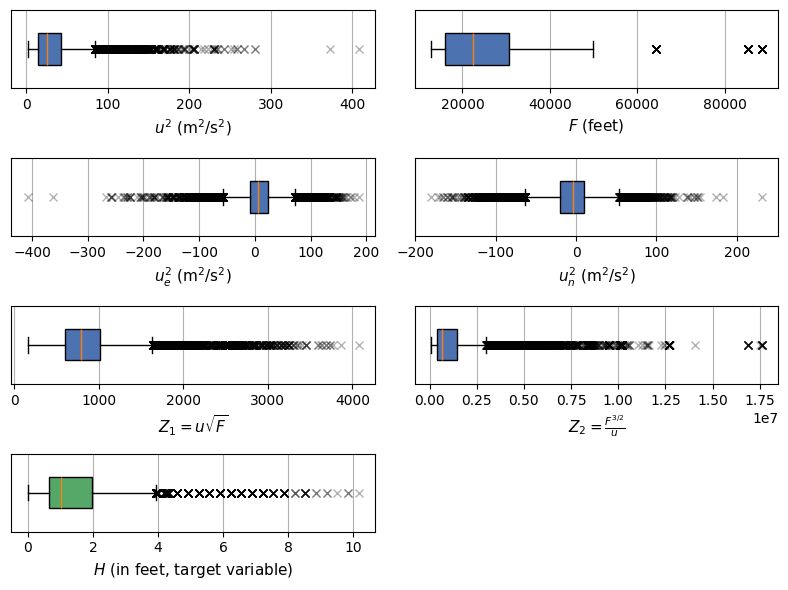

In [3]:
labels = [
    r'$u^2$ (m$^2$/s$^2$)', 
    r'$F$ (feet)', 
    r'$u^2_{e}$ (m$^2$/s$^2$)', 
    r'$u^2_{n}$ (m$^2$/s$^2$)', 
    r'$Z_1 = u\sqrt{F}$', 
    r'$Z_2 = \frac{F^{3/2}}{u}$'
]

fig, axs = plt.subplots(4, 2, figsize=(8, 6))
axs = axs.flatten()
flierprops = dict(marker='x', markerfacecolor='k', alpha=0.3)

for i, (col, label) in enumerate(zip(wind_cols, labels)):
    axs[i].boxplot(df1[col], vert=False, patch_artist=True, widths=0.4, boxprops=dict(facecolor='#4C72B0'), flierprops=flierprops)
    axs[i].set_xlabel(label, fontsize=11)
    axs[i].set_yticks([])
    axs[i].grid(True)

axs[6].boxplot(df1['H'], vert=False, patch_artist=True, widths=0.4, boxprops=dict(facecolor='#55A868'), flierprops=flierprops)
axs[6].set_xlabel(r'$H$ (in feet, target variable)', fontsize=11)
axs[6].set_yticks([])
axs[6].grid(True)
axs[7].axis('off')

plt.tight_layout()
plt.show()

### Correlation Analysis

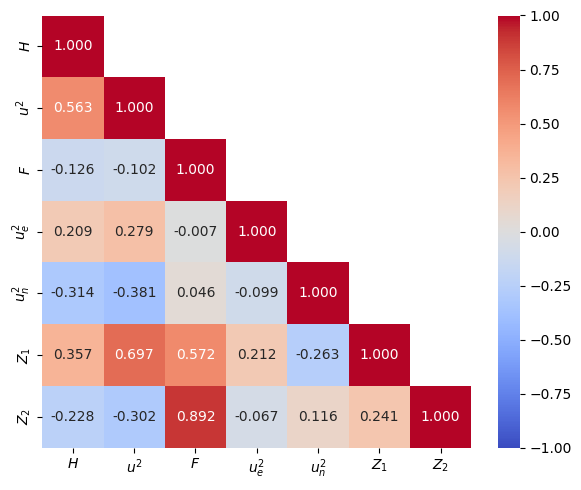

In [4]:
labels = [r'$H$', r'$u^2$', r'$F$', r'$u^2_{e}$', r'$u^2_{n}$', r'$Z_1$', r'$Z_2$']

df_corr = df1.corr()
df_corr.columns = labels
df_corr.index = labels

plt.figure(figsize=(6, 5))
sns.heatmap(df_corr, vmin=-1, vmax=1, center=0, fmt='.3f', annot=True, 
            cmap='coolwarm', mask=np.triu(np.ones_like(df_corr), 1))

plt.tight_layout()
plt.show()

### Kolmogorov-Smirnov (KS) Test

- **Two-sample KS test**: To compare the distributions of a feature between the training set and the test set
- **Null hypothesis**: There is no significant difference between the distributions of two datasets.

#### Comparison of feature distributions between the training and test sets

In [5]:
# Train-Test split
# df_train: [2004-11-01 00:00:00 ~ 2007-10-31 23:00:00, 2008-11-01 00:00:00 ~ 2013-10-31 23:00:00]
# df_test: [2007-11-01 00:00:00 ~ 2008-10-31 23:00:00]
split1 = pd.to_datetime('2007-10-31 23:59:00')
split2 = pd.to_datetime('2008-10-31 23:59:00')
df_train = df1[(df1.index < split1) | (df1.index > split2)]
df_test = df1[(df1.index > split1) & (df1.index < split2)]

# Data normalization
scaler = MinMaxScaler()
df_train_T = scaler.fit_transform(df_train)
df_test_T = scaler.transform(df_test)
df_train_T = pd.DataFrame(df_train_T, columns=df1.columns)
df_test_T = pd.DataFrame(df_test_T, columns=df1.columns)

# KS test
results = []
for col in df1.columns:
    statistic, p_value = ks_2samp(df_train_T[col], df_test_T[col])
    results.append((col, statistic, p_value))

ks_df = pd.DataFrame(results, columns=['Feature', 'KS Statistic', 'P-value'])
ks_df

,Feature,KS Statistic,P-value
0,H,0.024161,2.165789e-04
1,uSq,0.014083,8.958118e-02
2,F,0.008849,5.708129e-01
3,uSq_e,0.032287,1.668130e-07
4,uSq_n,0.020167,3.446459e-03
5,Z1,0.020694,2.462375e-03
6,Z2,0.012247,1.906394e-01


#### Comparison of feature distributions between the 2004-2013 and 1973-2004 datasets

In [6]:
# Drop columns
df1 = df1.drop(['H'], axis=1)

# Data normalization
scaler = MinMaxScaler()
df1_T = scaler.fit_transform(df1)
df2_T = scaler.transform(df2)
df1_T = pd.DataFrame(df1_T, columns=df1.columns)
df2_T = pd.DataFrame(df2_T, columns=df2.columns)

# KS test
results = []
for col in df1.columns:
    statistic, p_value = ks_2samp(df1_T[col], df2_T[col])
    results.append((col, statistic, p_value))

ks_df = pd.DataFrame(results, columns=['Feature', 'KS Statistic', 'P-value'])
ks_df

,Feature,KS Statistic,P-value
0,uSq,0.122588,0.000000e+00
1,F,0.042513,1.860662e-96
2,uSq_e,0.062811,3.844029e-210
3,uSq_n,0.038924,6.364082e-81
4,Z1,0.138416,0.000000e+00
5,Z2,0.042748,1.601888e-97
